In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

DATA_DIR = Path("../data")

train = pd.read_csv(DATA_DIR / "train.csv")
validation = pd.read_csv(DATA_DIR / "validation.csv")
test = pd.read_csv(DATA_DIR / "test_input.csv")
data_dictionary = pd.read_csv(DATA_DIR / "data_dictionary.csv")

print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)
print("Data Dictionary:", data_dictionary.shape)

Train: (34343, 51)
Validation: (7248, 51)
Test: (2352, 47)
Data Dictionary: (26, 4)


In [2]:
print("TRAIN COLUMNS")
for i, col in enumerate(train.columns, 1):
    print(i, col)

print("\n\nVALIDATION COLUMNS")
for i, col in enumerate(validation.columns, 1):
    print(i, col)

print("\n\nTEST COLUMNS")
for i, col in enumerate(test.columns, 1):
    print(i, col)

TRAIN COLUMNS
1 datetime
2 split
3 window_id
4 horizon_hour
5 dayOfWeek
6 weekend
7 hourOfDay
8 holiday
9 Holiday_ID
10 school
11 T2M_toc
12 QV2M_toc
13 TQL_toc
14 W2M_toc
15 T2M_san
16 QV2M_san
17 TQL_san
18 W2M_san
19 T2M_dav
20 QV2M_dav
21 TQL_dav
22 W2M_dav
23 national_week_X-2_mwh
24 national_week_X-3_mwh
25 national_week_X-4_mwh
26 national_MA_X-4_mwh
27 tocumen_week_X-2_mwh
28 tocumen_week_X-3_mwh
29 tocumen_week_X-4_mwh
30 tocumen_MA_X-4_mwh
31 santiago_week_X-2_mwh
32 santiago_week_X-3_mwh
33 santiago_week_X-4_mwh
34 santiago_MA_X-4_mwh
35 david_week_X-2_mwh
36 david_week_X-3_mwh
37 david_week_X-4_mwh
38 david_MA_X-4_mwh
39 tocumen_wind_gen_mwh
40 santiago_wind_gen_mwh
41 david_wind_gen_mwh
42 tocumen_solar_gen_mwh
43 santiago_solar_gen_mwh
44 david_solar_gen_mwh
45 total_wind_gen_mwh
46 total_solar_gen_mwh
47 total_vre_gen_mwh
48 nat_demand
49 load_tocumen_mwh
50 load_santiago_mwh
51 load_david_mwh


VALIDATION COLUMNS
1 datetime
2 split
3 window_id
4 horizon_hour
5 dayOfWeek

In [3]:
data_dictionary

,field,unit,description,role
0,datetime,timestamp,Panama local timestamp (UTC-05:00).,ID
1,split,categorical,"TRAIN, VALIDATION or TEST.",Partition
2,window_id,categorical,168-hour evaluation-window identifier.,Partition
3,horizon_hour,integer,"Hour within an evaluation window, 1-168; 0 for...",Partition
4,dayOfWeek,integer,"Saturday=1, Sunday=2, Monday=3, ..., Friday=7.",Feature
5,weekend,binary,1 Saturday/Sunday; 0 otherwise.,Feature
6,hourOfDay,integer,0-23.,Feature
7,holiday,binary,1 holiday; 0 regular day.,Feature
8,Holiday_ID,integer,Holiday identifier from supplied dataset.,Feature
9,school,binary,1 school period; 0 vacation period.,Feature


Data Quality Check

In [4]:
print("=== MISSING VALUES ===")
print(train.isna().sum().sort_values(ascending=False).head(15))

print("\n=== DUPLICATES ===")
print("Train:", train.duplicated().sum())
print("Validation:", validation.duplicated().sum())
print("Test:", test.duplicated().sum())

print("\n=== DATATYPES ===")
print(train.dtypes)

print("\n=== TARGETS ===")
targets = [
    "nat_demand",
    "load_tocumen_mwh",
    "load_santiago_mwh",
    "load_david_mwh"
]

print(train[targets].describe().T)

=== MISSING VALUES ===
window_id       34343
datetime            0
split               0
horizon_hour        0
dayOfWeek           0
weekend             0
hourOfDay           0
holiday             0
Holiday_ID          0
school              0
T2M_toc             0
QV2M_toc            0
TQL_toc             0
W2M_toc             0
T2M_san             0
dtype: int64

=== DUPLICATES ===
Train: 0
Validation: 0
Test: 0

=== DATATYPES ===
datetime                      str
split                         str
window_id                 float64
horizon_hour                int64
dayOfWeek                   int64
weekend                     int64
hourOfDay                   int64
holiday                     int64
Holiday_ID                  int64
school                      int64
T2M_toc                   float64
QV2M_toc                  float64
TQL_toc                   float64
W2M_toc                   float64
T2M_san                   float64
QV2M_san                  float64
TQL_san             

In [5]:
print("=== MISSING VALUES ===")
print("Train:", train.isna().sum().sum())
print("Validation:", validation.isna().sum().sum())
print("Test:", test.isna().sum().sum())

print("\n=== DUPLICATES ===")
print("Train:", train.duplicated().sum())
print("Validation:", validation.duplicated().sum())
print("Test:", test.duplicated().sum())

print("\n=== DATETIME ===")
print("Train:", train["datetime"].min(), "→", train["datetime"].max())
print("Validation:", validation["datetime"].min(), "→", validation["datetime"].max())
print("Test:", test["datetime"].min(), "→", test["datetime"].max())

print("\n=== TARGET SUMMARY ===")
targets = [
    "nat_demand",
    "load_tocumen_mwh",
    "load_santiago_mwh",
    "load_david_mwh"
]

print(train[targets].describe().round(2).to_string())

=== MISSING VALUES ===
Train: 34343
Validation: 0
Test: 0

=== DUPLICATES ===
Train: 0
Validation: 0
Test: 0

=== DATETIME ===
Train: 01-01-2016 00:00 → 31-12-2018 23:00
Validation: 01-01-2019 00:00 → 31-12-2019 23:00
Test: 01-06-2019 00:00 → 31-05-2019 23:00

=== TARGET SUMMARY ===
       nat_demand  load_tocumen_mwh  load_santiago_mwh  load_david_mwh
count    34343.00          34343.00           34343.00        34343.00
mean      1170.71            960.30              74.79          135.62
std        191.60            157.29              12.18           22.21
min        380.59            312.15              24.13           44.32
25%       1002.14            821.78              64.10          116.22
50%       1158.53            950.58              73.95          134.03
75%       1317.24           1080.86              84.07          152.32
max       1645.48           1350.92             105.42          192.94


In [6]:
print("=== MISSING COLUMNS IN TRAIN ===")
missing = train.isna().sum()
print(missing[missing > 0])

print("\n=== PARSED DATETIME RANGES ===")

for name, df in [("Train", train), ("Validation", validation), ("Test", test)]:
    dt = pd.to_datetime(df["datetime"], format="%d-%m-%Y %H:%M")
    print(f"{name}: {dt.min()} → {dt.max()}")

=== MISSING COLUMNS IN TRAIN ===
window_id    34343
dtype: int64

=== PARSED DATETIME RANGES ===
Train: 2015-01-31 01:00:00 → 2018-12-31 23:00:00
Validation: 2019-01-01 00:00:00 → 2019-12-31 23:00:00
Test: 2019-04-13 01:00:00 → 2020-06-20 00:00:00


In [7]:
print("=== HORIZON HOUR ===")
print("Train:", train["horizon_hour"].min(), "→", train["horizon_hour"].max())
print("Validation:", validation["horizon_hour"].min(), "→", validation["horizon_hour"].max())
print("Test:", test["horizon_hour"].min(), "→", test["horizon_hour"].max())

print("\n=== HORIZON DISTRIBUTION ===")
print(train["horizon_hour"].value_counts().sort_index().head(10))
print("...")
print(train["horizon_hour"].value_counts().sort_index().tail(10))

print("\n=== SPLIT VALUES ===")
print(train["split"].value_counts())
print(validation["split"].value_counts())
print(test["split"].value_counts())

=== HORIZON HOUR ===
Train: 0 → 0
Validation: 1 → 168
Test: 1 → 168

=== HORIZON DISTRIBUTION ===
horizon_hour
0    34343
Name: count, dtype: int64
...
horizon_hour
0    34343
Name: count, dtype: int64

=== SPLIT VALUES ===
split
TRAIN    34343
Name: count, dtype: int64
split
VALIDATION    7248
Name: count, dtype: int64
split
TEST    2352
Name: count, dtype: int64


In [8]:
print("=== VALIDATION SAMPLE ===")
display(
    validation[
        ["datetime", "horizon_hour",
         "dayOfWeek", "hourOfDay",
         "nat_demand"]
    ].head(10)
)

print("\n=== VALIDATION LAST 10 ===")
display(
    validation[
        ["datetime", "horizon_hour",
         "dayOfWeek", "hourOfDay",
         "nat_demand"]
    ].tail(10)
)

print("\n=== TEST SAMPLE ===")
display(
    test[
        ["datetime", "horizon_hour",
         "dayOfWeek", "hourOfDay"]
    ].head(10)
)

=== VALIDATION SAMPLE ===


,datetime,horizon_hour,dayOfWeek,hourOfDay,nat_demand
0,01-01-2019 00:00,1,4,0,1027.9238
1,01-01-2019 01:00,2,4,1,1006.3692
2,01-01-2019 02:00,3,4,2,990.4364
3,01-01-2019 03:00,4,4,3,975.8917
4,01-01-2019 04:00,5,4,4,949.1626
5,01-01-2019 05:00,6,4,5,931.3311
6,01-01-2019 06:00,7,4,6,914.5064
7,01-01-2019 07:00,8,4,7,908.2670
8,01-01-2019 08:00,9,4,8,958.5056
9,01-01-2019 09:00,10,4,9,993.1466



=== VALIDATION LAST 10 ===


,datetime,horizon_hour,dayOfWeek,hourOfDay,nat_demand
7238,31-12-2019 14:00,15,4,14,1272.5977
7239,31-12-2019 15:00,16,4,15,1250.3840
7240,31-12-2019 16:00,17,4,16,1223.4536
7241,31-12-2019 17:00,18,4,17,1193.3218
7242,31-12-2019 18:00,19,4,18,1287.3592
7243,31-12-2019 19:00,20,4,19,1301.6065
7244,31-12-2019 20:00,21,4,20,1250.9634
7245,31-12-2019 21:00,22,4,21,1193.6802
7246,31-12-2019 22:00,23,4,22,1130.4575
7247,31-12-2019 23:00,24,4,23,1084.4737



=== TEST SAMPLE ===


,datetime,horizon_hour,dayOfWeek,hourOfDay
0,13-04-2019 01:00,1,1,1
1,13-04-2019 02:00,2,1,2
2,13-04-2019 03:00,3,1,3
3,13-04-2019 04:00,4,1,4
4,13-04-2019 05:00,5,1,5
5,13-04-2019 06:00,6,1,6
6,13-04-2019 07:00,7,1,7
7,13-04-2019 08:00,8,1,8
8,13-04-2019 09:00,9,1,9
9,13-04-2019 10:00,10,1,10


In [9]:
print("=== WINDOWS ===")

for name, df in [("Validation", validation), ("Test", test)]:
    print(f"\n{name}")
    print("Number of unique window IDs:", df["window_id"].nunique())
    print("Rows per window:")
    print(df.groupby("window_id").size().value_counts().sort_index())
    
    print("\nFirst 5 windows:")
    print(
        df.groupby("window_id")["datetime"]
        .agg(["min", "max", "count"])
        .head()
    )

=== WINDOWS ===

Validation
Number of unique window IDs: 53
Rows per window:
24      1
71      9
97      9
168    34
Name: count, dtype: int64

First 5 windows:
                           min               max  count
window_id                                              
VAL_20190101  01-01-2019 00:00  07-01-2019 23:00    168
VAL_20190108  08-01-2019 00:00  14-01-2019 23:00    168
VAL_20190115  15-01-2019 00:00  21-01-2019 23:00    168
VAL_20190122  22-01-2019 00:00  28-01-2019 23:00    168
VAL_20190129  01-02-2019 00:00  31-01-2019 23:00    168

Test
Number of unique window IDs: 14
Rows per window:
168    14
Name: count, dtype: int64

First 5 windows:
                        min               max  count
window_id                                           
TEST_W01   13-04-2019 01:00  20-04-2019 00:00    168
TEST_W02   01-06-2019 00:00  31-05-2019 23:00    168
TEST_W03   15-06-2019 01:00  22-06-2019 00:00    168
TEST_W04   20-07-2019 01:00  27-07-2019 00:00    168
TEST_W05   17-08-201

In [11]:
window_info = (
    validation.groupby("window_id")
    .agg(
        rows=("datetime", "size"),
        start=("datetime", "min"),
        end=("datetime", "max"),
        min_horizon=("horizon_hour", "min"),
        max_horizon=("horizon_hour", "max")
    )
    .sort_values("start")
)

display(window_info.to_string())

'              rows             start               end  min_horizon  max_horizon\nwindow_id                                                                       \nVAL_20190101   168  01-01-2019 00:00  07-01-2019 23:00            1          168\nVAL_20190129   168  01-02-2019 00:00  31-01-2019 23:00            1          168\nVAL_20190226   168  01-03-2019 00:00  28-02-2019 23:00            1          168\nVAL_20190326   168  01-04-2019 00:00  31-03-2019 23:00            1          168\nVAL_20190430   168  01-05-2019 00:00  30-04-2019 23:00            1          168\nVAL_20190528    71  01-06-2019 01:00  03-06-2019 23:00            1           71\nVAL_20190625   168  01-07-2019 00:00  30-06-2019 23:00            1          168\nVAL_20190730   168  01-08-2019 00:00  31-07-2019 23:00            1          168\nVAL_20190827   168  01-09-2019 00:00  31-08-2019 23:00            1          168\nVAL_20191001   168  01-10-2019 00:00  07-10-2019 23:00            1          168\nVAL_20191029   

In [12]:
display(window_info.reset_index())

,window_id,rows,start,end,min_horizon,max_horizon
0,VAL_20190101,168,01-01-2019 00:00,07-01-2019 23:00,1,168
1,VAL_20190129,168,01-02-2019 00:00,31-01-2019 23:00,1,168
2,VAL_20190226,168,01-03-2019 00:00,28-02-2019 23:00,1,168
3,VAL_20190326,168,01-04-2019 00:00,31-03-2019 23:00,1,168
4,VAL_20190430,168,01-05-2019 00:00,30-04-2019 23:00,1,168
5,VAL_20190528,71,01-06-2019 01:00,03-06-2019 23:00,1,71
6,VAL_20190625,168,01-07-2019 00:00,30-06-2019 23:00,1,168
7,VAL_20190730,168,01-08-2019 00:00,31-07-2019 23:00,1,168
8,VAL_20190827,168,01-09-2019 00:00,31-08-2019 23:00,1,168
9,VAL_20191001,168,01-10-2019 00:00,07-10-2019 23:00,1,168


In [13]:
print("Complete validation windows:",
      (window_info["rows"] == 168).sum())

print("Partial validation windows:",
      (window_info["rows"] < 168).sum())

Complete validation windows: 34
Partial validation windows: 19


In [14]:
for name, df in [("Train", train), ("Validation", validation), ("Test", test)]:
    dt = pd.to_datetime(df["datetime"], format="%d-%m-%Y %H:%M")
    
    gaps = dt.sort_values().diff().value_counts().head(5)
    
    print(f"\n{name}")
    print(gaps)


Train
datetime
0 days 01:00:00    34342
Name: count, dtype: int64

Validation
datetime
0 days 01:00:00    7238
7 days 01:00:00       9
Name: count, dtype: int64

Test
datetime
0 days 01:00:00     2338
21 days 01:00:00       5
14 days 01:00:00       2
28 days 01:00:00       2
35 days 01:00:00       1
Name: count, dtype: int64


In [15]:
print("=== FEATURES WITH DIFFERENT TRAIN/VALIDATION/TEST AVAILABILITY ===")

for col in train.columns:
    if col not in validation.columns or col not in test.columns:
        print(col)

=== FEATURES WITH DIFFERENT TRAIN/VALIDATION/TEST AVAILABILITY ===
nat_demand
load_tocumen_mwh
load_santiago_mwh
load_david_mwh


In [16]:
print("Train columns:", len(train.columns))
print("Validation columns:", len(validation.columns))
print("Test columns:", len(test.columns))

print("\nColumns missing from TEST:")
print(sorted(set(train.columns) - set(test.columns)))

Train columns: 51
Validation columns: 51
Test columns: 47

Columns missing from TEST:
['load_david_mwh', 'load_santiago_mwh', 'load_tocumen_mwh', 'nat_demand']


In [17]:
targets = [
    "nat_demand",
    "load_tocumen_mwh",
    "load_santiago_mwh",
    "load_david_mwh"
]

features = [col for col in test.columns if col not in targets]

print("Number of candidate features:", len(features))

for i, col in enumerate(features, 1):
    print(f"{i:2}. {col}")

Number of candidate features: 47
 1. datetime
 2. split
 3. window_id
 4. horizon_hour
 5. dayOfWeek
 6. weekend
 7. hourOfDay
 8. holiday
 9. Holiday_ID
10. school
11. T2M_toc
12. QV2M_toc
13. TQL_toc
14. W2M_toc
15. T2M_san
16. QV2M_san
17. TQL_san
18. W2M_san
19. T2M_dav
20. QV2M_dav
21. TQL_dav
22. W2M_dav
23. national_week_X-2_mwh
24. national_week_X-3_mwh
25. national_week_X-4_mwh
26. national_MA_X-4_mwh
27. tocumen_week_X-2_mwh
28. tocumen_week_X-3_mwh
29. tocumen_week_X-4_mwh
30. tocumen_MA_X-4_mwh
31. santiago_week_X-2_mwh
32. santiago_week_X-3_mwh
33. santiago_week_X-4_mwh
34. santiago_MA_X-4_mwh
35. david_week_X-2_mwh
36. david_week_X-3_mwh
37. david_week_X-4_mwh
38. david_MA_X-4_mwh
39. tocumen_wind_gen_mwh
40. santiago_wind_gen_mwh
41. david_wind_gen_mwh
42. tocumen_solar_gen_mwh
43. santiago_solar_gen_mwh
44. david_solar_gen_mwh
45. total_wind_gen_mwh
46. total_solar_gen_mwh
47. total_vre_gen_mwh


In [18]:
profile = pd.DataFrame({
    "dtype": test.dtypes,
    "unique_values": test.nunique(),
    "missing": test.isna().sum()
})

display(profile)

,dtype,unique_values,missing
datetime,str,2352,0
split,str,1,0
window_id,str,14,0
horizon_hour,int64,168,0
dayOfWeek,int64,7,0
weekend,int64,2,0
hourOfDay,int64,24,0
holiday,int64,2,0
Holiday_ID,int64,10,0
school,int64,2,0


In [19]:
time_features = [
    "dayOfWeek", "weekend", "hourOfDay",
    "holiday", "Holiday_ID", "school",
    "horizon_hour"
]

weather_features = [
    "T2M_toc", "QV2M_toc", "TQL_toc", "W2M_toc",
    "T2M_san", "QV2M_san", "TQL_san", "W2M_san",
    "T2M_dav", "QV2M_dav", "TQL_dav", "W2M_dav"
]

demand_features = [
    col for col in test.columns
    if "week_X" in col or "MA_X" in col
]

renewable_features = [
    col for col in test.columns
    if "gen_mwh" in col
]

print("Time/Calendar:", len(time_features))
print("Weather:", len(weather_features))
print("Historical Demand:", len(demand_features))
print("Renewable:", len(renewable_features))

print("\nHistorical demand features:")
print(demand_features)

print("\nRenewable features:")
print(renewable_features)

Time/Calendar: 7
Weather: 12
Historical Demand: 16
Renewable: 9

Historical demand features:
['national_week_X-2_mwh', 'national_week_X-3_mwh', 'national_week_X-4_mwh', 'national_MA_X-4_mwh', 'tocumen_week_X-2_mwh', 'tocumen_week_X-3_mwh', 'tocumen_week_X-4_mwh', 'tocumen_MA_X-4_mwh', 'santiago_week_X-2_mwh', 'santiago_week_X-3_mwh', 'santiago_week_X-4_mwh', 'santiago_MA_X-4_mwh', 'david_week_X-2_mwh', 'david_week_X-3_mwh', 'david_week_X-4_mwh', 'david_MA_X-4_mwh']

Renewable features:
['tocumen_wind_gen_mwh', 'santiago_wind_gen_mwh', 'david_wind_gen_mwh', 'tocumen_solar_gen_mwh', 'santiago_solar_gen_mwh', 'david_solar_gen_mwh', 'total_wind_gen_mwh', 'total_solar_gen_mwh', 'total_vre_gen_mwh']


In [20]:
target_corr = train[targets].corr()

display(target_corr.round(3))

,nat_demand,load_tocumen_mwh,load_santiago_mwh,load_david_mwh
nat_demand,1.000,1.000,0.998,0.998
load_tocumen_mwh,1.000,1.000,0.997,0.997
load_santiago_mwh,0.998,0.997,1.000,0.999
load_david_mwh,0.998,0.997,0.999,1.000


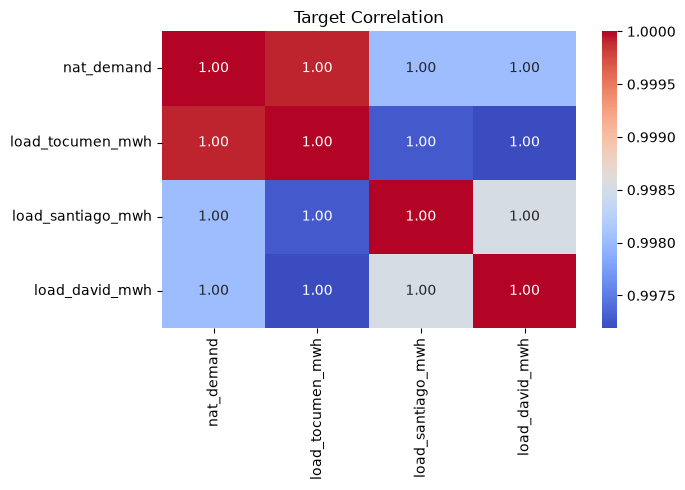

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.heatmap(target_corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Target Correlation")
plt.tight_layout()
plt.show()

In [22]:
print(train[targets].describe().T[["mean", "std", "min", "max"]].round(2))

                      mean     std     min      max
nat_demand         1170.71  191.60  380.59  1645.48
load_tocumen_mwh    960.30  157.29  312.15  1350.92
load_santiago_mwh    74.79   12.18   24.13   105.42
load_david_mwh      135.62   22.21   44.32   192.94


In [23]:
display(
    train[demand_features].describe().T[
        ["mean", "std", "min", "max"]
    ].round(2)
)

,mean,std,min,max
national_week_X-2_mwh,1169.44,191.93,380.59,1645.48
national_week_X-3_mwh,1168.83,191.86,380.59,1645.48
national_week_X-4_mwh,1168.26,191.76,380.59,1645.48
national_MA_X-4_mwh,1169.19,184.09,793.60,1576.78
tocumen_week_X-2_mwh,959.26,157.56,312.15,1350.92
tocumen_week_X-3_mwh,958.75,157.51,312.15,1350.92
tocumen_week_X-4_mwh,958.28,157.42,312.15,1350.92
tocumen_MA_X-4_mwh,959.05,151.07,650.57,1291.96
santiago_week_X-2_mwh,74.71,12.20,24.13,105.42
santiago_week_X-3_mwh,74.67,12.20,24.13,105.42


In [25]:
print("Historical-demand feature correlations with targets:\n")

corr = train[demand_features + targets].corr()[targets].drop(targets)

display(corr.round(3))

Historical-demand feature correlations with targets:



,nat_demand,load_tocumen_mwh,load_santiago_mwh,load_david_mwh
national_week_X-2_mwh,0.885,0.885,0.884,0.885
national_week_X-3_mwh,0.884,0.884,0.882,0.883
national_week_X-4_mwh,0.885,0.885,0.883,0.885
national_MA_X-4_mwh,0.927,0.926,0.925,0.926
tocumen_week_X-2_mwh,0.885,0.884,0.883,0.884
tocumen_week_X-3_mwh,0.883,0.883,0.881,0.882
tocumen_week_X-4_mwh,0.884,0.884,0.882,0.884
tocumen_MA_X-4_mwh,0.926,0.926,0.925,0.926
santiago_week_X-2_mwh,0.885,0.885,0.886,0.886
santiago_week_X-3_mwh,0.885,0.884,0.885,0.885


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

complete_windows = window_info[window_info["rows"] == 168].index

val_complete = validation[
    validation["window_id"].isin(complete_windows)
].copy()

baseline_map = {
    "nat_demand": "national_MA_X-4_mwh",
    "load_tocumen_mwh": "tocumen_MA_X-4_mwh",
    "load_santiago_mwh": "santiago_MA_X-4_mwh",
    "load_david_mwh": "david_MA_X-4_mwh"
}

baseline_results = []

for target, pred_col in baseline_map.items():
    y_true = val_complete[target]
    y_pred = val_complete[pred_col]

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)

    baseline_results.append({
        "Target": target,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "R²": r2
    })

baseline_results = pd.DataFrame(baseline_results)

display(baseline_results.round(4))

,Target,MAE,RMSE,MAPE (%),R²
0,nat_demand,56.6431,82.3663,4.9416,0.8112
1,load_tocumen_mwh,46.5414,67.6363,4.9548,0.8101
2,load_santiago_mwh,3.6639,5.2865,4.9802,0.8127
3,load_david_mwh,6.5945,9.6065,4.9308,0.8136


In [28]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Use only the original candidate features
baseline_features = (
    [f for f in time_features if f != "horizon_hour"]
    + weather_features
    + demand_features
    + renewable_features
)

X_train = train[baseline_features]
X_val = val_complete[baseline_features]

ml_results = []
ml_predictions = {}

for target in targets:
    print(f"Training: {target}")

    model = XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, train[target])

    y_true = val_complete[target]
    y_pred = model.predict(X_val)

    ml_predictions[target] = y_pred

    ml_results.append({
        "Target": target,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE (%)": np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
        "R²": r2_score(y_true, y_pred)
    })

ml_results = pd.DataFrame(ml_results)

display(ml_results.round(4))

Training: nat_demand
Training: load_tocumen_mwh
Training: load_santiago_mwh
Training: load_david_mwh


,Target,MAE,RMSE,MAPE (%),R²
0,nat_demand,47.3920,66.2929,4.1744,0.8777
1,load_tocumen_mwh,38.5524,54.0085,4.1511,0.8789
2,load_santiago_mwh,3.0555,4.2523,4.2000,0.8788
3,load_david_mwh,5.5522,7.7570,4.2008,0.8784


## Conclusion

In this notebook, we first understood the structure of the electricity forecasting dataset, including the train, validation and test sets, the 168 hour forecasting windows, the four target variables, and the different groups of available features.

We found that the training data is continuous hourly data with no duplicate rows, while the validation and test sets are organized into separate forecasting windows. The historical demand features showed a strong relationship with all four targets, especially the 4 week moving average features.

We established two benchmarks. The simple 4 week moving average baseline achieved around 4.9% MAPE and 0.81 R², while the initial XGBoost model improved this to roughly 4.2% MAPE and 0.878 R² across the four targets.

This gives us a strong starting point. The next step is to investigate the data more deeply through EDA and then engineer additional features that can capture temporal, demand, weather and renewable generation patterns.